# **필요한 라이브러리 불러오기**
- https://pytorch.org/docs/stable/nn.html

In [ ]:
import torch
import torch.nn as nn

# torchvision : 효율적인 이미지 변환을 위한 computer vision 용 라이브러리
import torchvision.datasets as datasets         # dataset download를 위한 패키지
import torchvision.transforms as transforms     # 데이터 변환을 위한 패키지

import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
# device : gpu를 사용할 경우에는 'cuda', 그렇지 않을 경우에는 'cpu'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 랜덤 시드 고정
# 실험 조건을 동일하게 설정하여 같은 input을 넣으면 같은 결과가 나올 수 있도록 함
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

# **Hyper parameter 설정**

## ✏️ TODO: Hyperparameter 설정하기

모델 학습에 사용할 Hyperparameter를 작성하세요.

- `batch_size`: 한 번에 학습할 데이터 개수
- `epochs`: 전체 학습 데이터의 반복 횟수
- `learning_rate`: 가중치의 변화 정도

In [ ]:
# 학습에 사용할 값을 작성하세요.
batch_size = ____
epochs = ____
learning_rate = ____

# **MNIST 데이터셋 불러오기**
- 60,000개의 train data, 10,000개의 test data
- transforms.Normalize : 이미지 값의 범위를 조정함으로써 학습 안정화

## ✏️ TODO: 학습·테스트 데이터와 데이터 순서 설정하기

PPT를 참고하여 `train`과 `shuffle`의 빈칸에 `True` 또는 `False`를 작성하세요.

- `train_dataset`의 `train`: 학습 데이터를 선택하도록 설정하세요.
- `test_dataset`의 `train`: 테스트 데이터를 선택하도록 설정하세요.
- `train_loader`의 `shuffle`: 매 epoch마다 학습 데이터의 순서를 섞도록 설정하세요.
- `test_loader`의 `shuffle`: 테스트 데이터의 순서를 유지하도록 설정하세요.

`train`은 불러올 데이터의 종류를, `shuffle`은 데이터를 읽는 순서를 결정합니다.

In [ ]:
train_dataset = datasets.MNIST(root='dataset/', # 다운로드 경로 지정
                               train=____,     # TODO: 학습 데이터 선택
                               download=True,
                               transform=transforms.Compose([transforms.ToTensor(), # 텐서로 변환
                                                             transforms.Normalize(mean=(0.5),std=(0.5))])) # 이미지 표준화
test_dataset = datasets.MNIST(root='dataset/',
                              train=____,      # TODO: 테스트 데이터 선택
                              download=True,
                              transform=transforms.Compose([transforms.ToTensor(),
                                                            transforms.Normalize(mean=(0.5),std=(0.5))]))

# Data loader를 사용하여 배치 크기로 묶어주기
train_loader=torch.utils.data.DataLoader(train_dataset,
                                        batch_size=batch_size,
                                        shuffle=____) # TODO: 학습 데이터 순서 섞기
test_loader = torch.utils.data.DataLoader(test_dataset,
                                         batch_size=batch_size,
                                         shuffle=____) # TODO: 테스트 데이터 순서 유지

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting dataset/MNIST/raw/train-images-idx3-ubyte.gz to dataset/MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting dataset/MNIST/raw/train-labels-idx1-ubyte.gz to dataset/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting dataset/MNIST/raw/t10k-images-idx3-ubyte.gz to dataset/MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting dataset/MNIST/raw/t10k-labels-idx1-ubyte.gz to dataset/MNIST/raw



# **데이터 시각화**

In [ ]:
# 첫번째 데이터 묶음 반환
images, labels = next(iter(train_loader))

# 데이터 size 확인
images.shape , labels.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

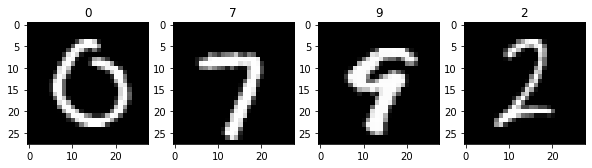

In [ ]:
img = images.squeeze(1).numpy()     # squeeze로 차원 축소 : [batch, 1, H, W] -> [batch, H, W]
label = labels.numpy()

plt.figure(figsize=(10,20))
plt.subplot(1,4,1)
plt.imshow(img[0],'gray')
plt.title(label[0])
plt.subplot(1,4,2)
plt.imshow(img[1],'gray')
plt.title(label[1])
plt.subplot(1,4,3)
plt.imshow(img[2],'gray')
plt.title(label[2])
plt.subplot(1,4,4)
plt.imshow(img[3],'gray')
plt.title(label[3])
plt.show()

# **모델 설계**
- Multi-layer Perceptron

## ✏️ TODO: MLP의 각 계층 입출력 크기 설정하기

PPT를 참고하여 각 `nn.Linear()`의 입력 크기와 출력 크기를 작성하세요.

- `nn.Linear(입력 크기, 출력 크기)` 형식으로 작성합니다.
- 첫 번째 계층의 입력 크기는 MNIST 이미지 한 장의 전체 픽셀 수입니다.
- 각 은닉층의 뉴런 수는 PPT에 제시된 모델 구조를 확인하세요.
- 이전 계층의 출력 크기와 다음 계층의 입력 크기가 일치해야 합니다.
- 마지막 출력층의 출력 크기는 분류할 숫자 클래스의 개수입니다.

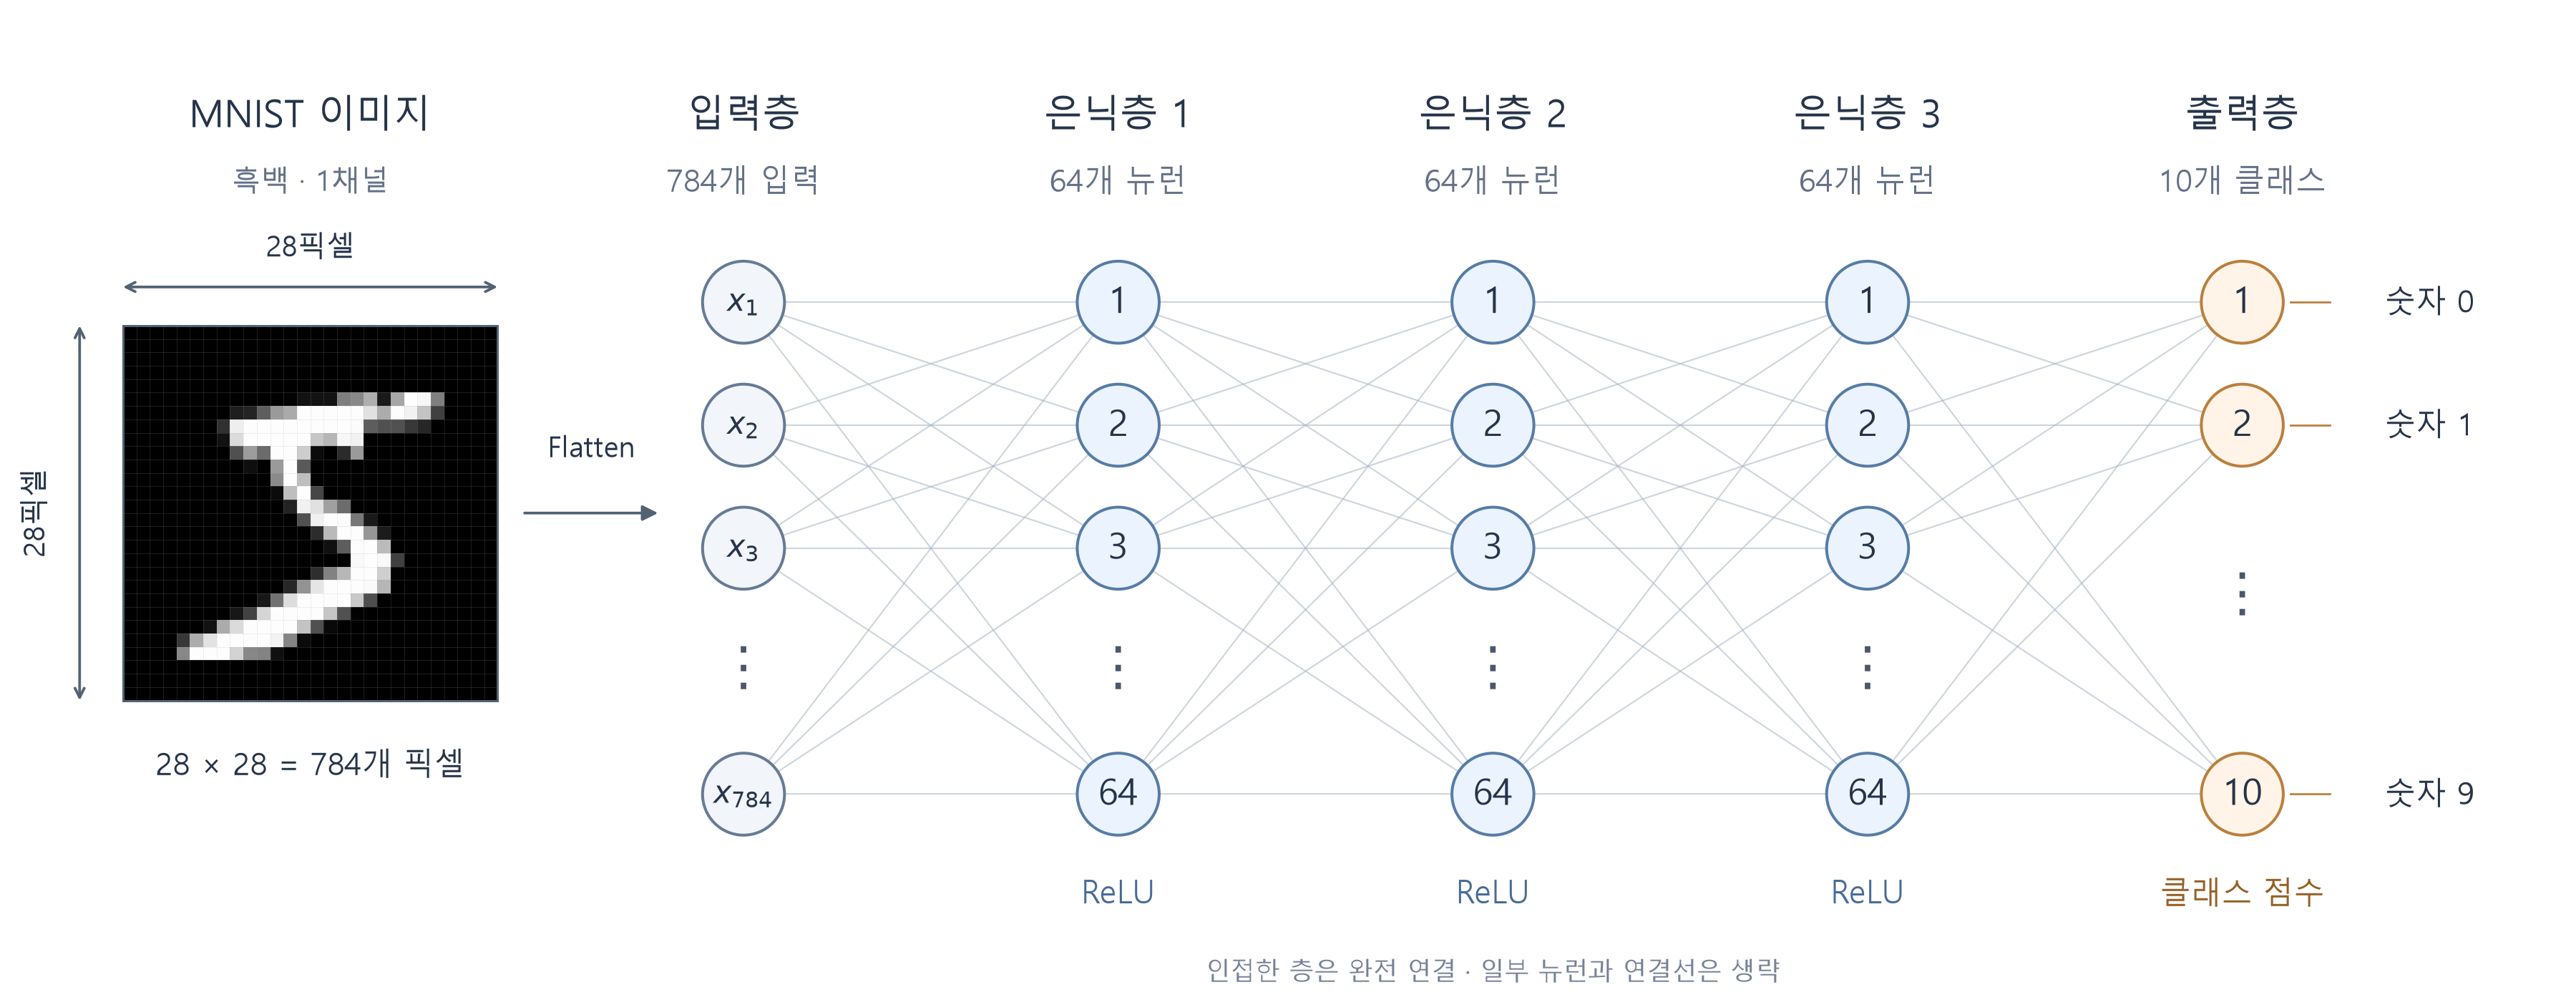

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP,self).__init__()
        self.layer1 = nn.Sequential(nn.Linear(____, ____),   # input : 1 x 28 x 28 = 784 -> output : 64
                                   nn.ReLU())              # activation function은 relu를 사용
        self.layer2 = nn.Sequential(nn.Linear(____, ____),   # input : 64 -> output : 64
                                   nn.ReLU())
        self.layer3 = nn.Sequential(nn.Linear(____, ____),   # input : 64 -> output : 64
                                   nn.ReLU())
        self.layer4 = nn.Linear(____, ____)                 # input : 64 -> output : 분류해야 할 총 class 수 = 10

    def forward(self, x):
        x = x.view(-1, 28 * 28)   # 2D 이미지 (batch, channel, height, width) -> 1D 배열 (batch, height x width) 로 flatten
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return x

model = MLP().to(device)   # GPU에서 연산 수행하기 위해 device로 보냄

In [ ]:
# 모델 구조 출력
print(model)

MLP(
  (layer1): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer3): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer4): Linear(in_features=64, out_features=10, bias=True)
)


# **Train**
- optimizer : 딥러닝 학습에 많이 사용되고 있는 Adam optimizer를 사용

![optimizer](https://machinelearningmastery.com/wp-content/uploads/2017/05/Comparison-of-Adam-to-Other-Optimization-Algorithms-Training-a-Multilayer-Perceptron.png)

- [다양한 optimizer 종류 및 설명 link](https://velog.io/@yookyungkho/%EB%94%A5%EB%9F%AC%EB%8B%9D-%EC%98%B5%ED%8B%B0%EB%A7%88%EC%9D%B4%EC%A0%80-%EC%A0%95%EB%B3%B5%EA%B8%B0%EB%B6%80%EC%A0%9C-CS231n-Lecture7-Review)

## ✏️ TODO: Adam Optimizer 설정하기

모델 학습에 사용할 Adam Optimizer를 직접 작성하세요.

- `torch.optim.Adam()`을 사용합니다.
- 학습할 모델의 Parameter를 전달합니다.
- 앞에서 설정한 `learning_rate`를 적용합니다.
- 아래 주석 위치에 Optimizer 정의 코드를 한 줄로 작성하세요.
- 학습 완료 후 SGD Optimizer로 변경하여 Loss와 Accuracy를 비교해 보세요.

In [ ]:
# cost function과 optimizer 정의
criterion = nn.CrossEntropyLoss().to(device)
optimizer =
## optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [ ]:
# 모델 학습
model.train() # 모델을 train mode로 설정
loss_list = []

for epoch in range(epochs):
  avg_loss = 0.0
  total_loss = 0.0
  for iter, data in enumerate(train_loader):

    # 매개변수 경사도 초기화
    optimizer.zero_grad()
    images, labels = data
    images = images.to(device)
    labels = labels.to(device)

    # 예측값 계산
    output = model(images)

    # Loss 계산
    loss = criterion(output,labels)

    # Backpropagation : 학습 가능한 매개변수에 대해 Loss의 변화도 계산
    loss.backward()

    # Weight 갱신
    optimizer.step()

    avg_loss += loss.item()
    total_loss += loss.item()

    # Iteration 100번째 마다 loss 출력하여 확인
    if (iter+1) % 100 == 0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.5f}'.format(
      epoch, iter+1, len(train_loader), avg_loss/100.))
      avg_loss = 0.0
  loss_list.append(total_loss/(iter+1))
print('\nLearning finished!')

Train Epoch: 0 [100/469]	Loss: 1.19097
Train Epoch: 0 [200/469]	Loss: 0.46479
Train Epoch: 0 [300/469]	Loss: 0.37875
Train Epoch: 0 [400/469]	Loss: 0.33942
Train Epoch: 1 [100/469]	Loss: 0.28053
Train Epoch: 1 [200/469]	Loss: 0.26736
Train Epoch: 1 [300/469]	Loss: 0.25478
Train Epoch: 1 [400/469]	Loss: 0.22689
Train Epoch: 2 [100/469]	Loss: 0.20943
Train Epoch: 2 [200/469]	Loss: 0.19418
Train Epoch: 2 [300/469]	Loss: 0.19370
Train Epoch: 2 [400/469]	Loss: 0.18209
Train Epoch: 3 [100/469]	Loss: 0.17118
Train Epoch: 3 [200/469]	Loss: 0.15075
Train Epoch: 3 [300/469]	Loss: 0.16132
Train Epoch: 3 [400/469]	Loss: 0.14311
Train Epoch: 4 [100/469]	Loss: 0.14381
Train Epoch: 4 [200/469]	Loss: 0.13404
Train Epoch: 4 [300/469]	Loss: 0.13257
Train Epoch: 4 [400/469]	Loss: 0.13053
Train Epoch: 5 [100/469]	Loss: 0.11713
Train Epoch: 5 [200/469]	Loss: 0.11413
Train Epoch: 5 [300/469]	Loss: 0.12236
Train Epoch: 5 [400/469]	Loss: 0.11793
Train Epoch: 6 [100/469]	Loss: 0.09643
Train Epoch: 6 [200/469]	

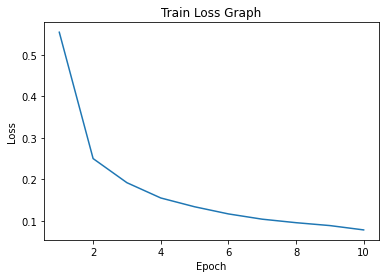

In [ ]:
# Loss graph
plt.plot(range(1,epochs+1), loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train Loss Graph')
plt.show()

# **Test**

In [ ]:
# 모델 성능 확인
with torch.no_grad(): # torch.no_grad(): gradient 계산을 수행하지 않음
  model.eval()        # 모델을 evaluation mode로 설정
  accuracy = 0.0

  for iter, data in enumerate(test_loader):
    images, labels = data
    images = images.to(device)
    labels = labels.to(device)
    output = model(images)

    # 모델이 예측한 값과 실제 레이블인 labels를 비교
    # argmax 함수를 이용해 예측한 값 중 가장 확률이 높은 값을 예측 값으로 사용 (예) [0.1,0.05,0.7,0,0,0.15] -> 2
    pred = torch.argmax(output,1) == labels
    accuracy += pred.float().sum()

  print("Accuracy : {:.2f}%".format(100*accuracy/len(test_dataset)))

Accuracy : 96.75%


Label:  0
Prediction:  0


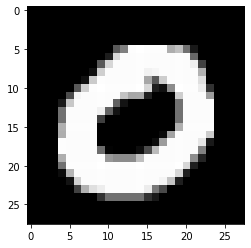

In [ ]:
with torch.no_grad():
  # 테스트 데이터에서 무작위로 하나를 뽑아서 예측
  r = random.randint(0, len(test_dataset) - 1)        # 랜덤한 정수 값
  image_data = test_dataset.data[r:r + 1].view(1, 1, 28, 28).float().to(device) # r번째 이미지 데이터
  label_data = test_dataset.targets[r:r + 1].to(device)                         # r번째 label 데이터

  print('Label: ', label_data.item())
  prediction = model(image_data)        # 예측값 계산
  print('Prediction: ', torch.argmax(prediction, 1).item())

  plt.imshow(test_dataset.data[r:r + 1].view(28, 28), cmap='gray')    # r번째 이미지 시각화
  plt.show()

# **모델 저장**

In [ ]:
# 모델의 weight만 저장
torch.save(model.state_dict(),'mlp_weight.pth')

In [ ]:
# 모델 통째로 저장
torch.save(model,'mlp.pth')

# **저장된 모델 불러오기**

In [ ]:
# 모델의 weight만 불러오기
checkpoint = torch.load('mlp_weight.pth', map_location = device)
model.load_state_dict(checkpoint)
model.eval()

MLP(
  (layer1): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer3): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer4): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
# 모델 통째로 불러오기
model = torch.load('mlp.pth', map_location = device)
model.eval()

MLP(
  (layer1): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer3): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
  (layer4): Linear(in_features=64, out_features=10, bias=True)
)